In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, f1_score, accuracy_score
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from sklearn.utils import class_weight

import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import EarlyStopping
from scipy.stats import pearsonr

from functions.nn import *
from functions.report import *

from fpdf import FPDF
import os
import ta

from collections import defaultdict

import joblib
import MetaTrader5 as mt5
import datetime
import time
import pytz

#### model for the bot

In [ ]:
data = pd.read_csv('training_data/eurusd_dataset_2025.csv')
data = data.drop(['Date_Time'], axis=1)

X = data.drop(['label'], axis=1)
y = data['label'].astype(int)

In [ ]:
cost_per_trade = 1.5  # in pips

pip_value_per_standard_lot = 10 # Assuming EUR/USD and USD account (this is for a standard lot)
initial_account_balance = 10000.0
risk_per_trade_percentage = 0.01

close_prices = X['Close'].values
highs_full = X['High'].values
lows_full = X['Low'].values

# If any are 1-element tuples, extract the array
if isinstance(highs_full, tuple) and len(highs_full) == 1:
    highs_full = highs_full[0]
if isinstance(lows_full, tuple) and len(lows_full) == 1:
    lows_full = lows_full[0]
if isinstance(close_prices, tuple) and len(close_prices) == 1:
    close_prices = close_prices[0]

# Tracking
f1_per_window, acc_per_window, trade_per_window, profit_per_window = [], [], [], []
window_indices = []

current_account_balance_at_window_start = initial_account_balance

class_to_direction = {0: -1, 1: -1, 2: 0, 3: 1, 4: 1}

# Prediction horizon
steps = int(7)
extra_steps = 0

# Parameters
window_size = -5000
# Standardize per window
scaler = StandardScaler()
scaler.fit(X[window_size : ])

# Transform both the training data and the validation data
train_X = scaler.transform(X[window_size : ])

train_y = y[window_size : ]
train_y_cat = to_categorical(train_y, num_classes=5)

input_features = train_X.shape[1]

close_prices_window = close_prices[window_size : ]
highs_window = highs_full[window_size : ]
lows_window = lows_full[window_size : ]
    
# 2. Optimize SL/TP on training window
sl_tp_map = optimize_sl_tp_per_class(
    y=train_y,
    close_prices=close_prices_window,
    highs=highs_window,
    lows=lows_window,
    sl_values=[8, 10, 12, 15, 20],
    tp_values=[10, 12, 15, 20, 25],
    class_to_direction=class_to_direction,
    cost_per_trade=cost_per_trade
)

# 3. Estimate label horizon per class
# Fui ver e isto varia bastante entre as windows por isso deixar
avg_duration_by_class = estimate_avg_duration_per_class(
    y=train_y,
    close_prices=close_prices_window,
    highs=highs_window,
    lows=lows_window,
    sl_tp_map=sl_tp_map,
    class_to_direction=class_to_direction
)

cw = dict(enumerate(class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(train_y), y=train_y)))

# removed the validation set from the model training
model = build_model_nn(input_features)
model.fit(train_X, train_y_cat,
            epochs=30, batch_size=32,
            class_weight=cw,
            verbose=0)

bundle = {
    'sl_tp_map': sl_tp_map,
    'avg_duration_by_class': avg_duration_by_class,
    'model': model,
    'scaler': scaler
}

bundle_filename = 'eurusd_model.joblib'

joblib.dump(bundle, bundle_filename)

['eurusd_model.joblib']

#### Model building (old)

In [3]:
data = pd.read_csv('training_data/eurusd_dataset_2025.csv')
data = data.drop(['Date_Time'], axis=1)

X = data.drop(['label'], axis=1)
y = data['label'].astype(int)

In [ ]:
# Parameters
window_size = 5000
val_size = 1000
step = 1000

cost_per_trade = 1.5  # in pips

pip_value_per_standard_lot = 10 # Assuming EUR/USD and USD account (this is for a standard lot)
initial_account_balance = 10000.0
risk_per_trade_percentage = 0.01

close_prices = X['Open'].values
highs_full = X['High'].values
lows_full = X['Low'].values

# If any are 1-element tuples, extract the array
if isinstance(highs_full, tuple) and len(highs_full) == 1:
    highs_full = highs_full[0]
if isinstance(lows_full, tuple) and len(lows_full) == 1:
    lows_full = lows_full[0]
if isinstance(close_prices, tuple) and len(close_prices) == 1:
    close_prices = close_prices[0]

# Tracking
f1_per_window, acc_per_window, trade_per_window, profit_per_window = [], [], [], []
window_indices = []

current_account_balance_at_window_start = initial_account_balance

class_to_direction = {0: -1, 1: -1, 2: 0, 3: 1, 4: 1}

# Prediction horizon
steps = int(7)  # 7 candles
extra_steps = 0  # No extra steps for now

# window_length = 64

winning_trades = 0
losing_trades = 0

# Add tracking structures at the top
profit_per_class = defaultdict(float)
trades_per_class = defaultdict(int)

for i, start in enumerate(range(0, len(X) - window_size - val_size - steps, step)):

    # Standardize per window
    scaler = StandardScaler()
    scaler.fit(X[start : start + window_size])

    # Transform both the training data and the validation data
    X_scaled_train = scaler.transform(X[start : start + window_size])
    X_scaled_val = scaler.transform(X[start + window_size : start + window_size + val_size])
    train_X = X_scaled_train
    val_X = X_scaled_val

    val_y = y[start+window_size:start+window_size+val_size]
    val_y_cat = to_categorical(val_y, num_classes=5)

    train_y = y[start:start+window_size]
    train_y_cat = to_categorical(train_y, num_classes=5)

    input_features = train_X.shape[1]

    close_prices_window = close_prices[start:start + window_size]
    highs_window = highs_full[start:start + window_size]
    lows_window = lows_full[start:start + window_size]

    # train_X_seq, train_y_seq = create_lstm_sequences(train_X, train_y_cat, window_length)
    # val_X_seq, val_y_seq = create_lstm_sequences(val_X, val_y_cat, window_length)

    # 2. Optimize SL/TP on training window
    sl_tp_map = optimize_sl_tp_per_class(
        y=train_y,
        close_prices=close_prices_window,
        highs=highs_window,
        lows=lows_window,
        sl_values=[8, 10, 12, 15, 20],
        tp_values=[10, 12, 15, 20, 25],
        class_to_direction=class_to_direction,
        cost_per_trade=cost_per_trade
    )

    # 3. Estimate label horizon per class
    # Fui ver e isto varia bastante entre as windows por isso deixar
    avg_duration_by_class = estimate_avg_duration_per_class(
        y=train_y,
        close_prices=close_prices_window,
        highs=highs_window,
        lows=lows_window,
        sl_tp_map=sl_tp_map,
        class_to_direction=class_to_direction
    )

    cw = dict(enumerate(class_weight.compute_class_weight(
        class_weight='balanced', classes=np.unique(train_y), y=train_y)))

    # removed the validation set from the model training
    model = build_model_nn(input_features)
    model.fit(train_X, train_y_cat,
              epochs=30, batch_size=32,
              class_weight=cw,
              verbose=0)

    preds = np.argmax(model.predict(val_X, verbose=0), axis=1)
    # val_y_seq_labels = np.argmax(val_y, axis=1)

    f1 = f1_score(val_y, preds, average='weighted')
    acc = accuracy_score(val_y, preds)

    # Trade simulation
    val_start = start + window_size
    max_len = min(val_size, len(data) - val_start - steps)

    profit = 0.0
    trades = 0.0

    running_balance_in_window = current_account_balance_at_window_start

    # Fix tuple issue for close_prices and highs_full
    close_prices_arr = close_prices[0] if isinstance(close_prices, tuple) else close_prices
    highs_full_arr = highs_full[0] if isinstance(highs_full, tuple) else highs_full
    lows_full_arr = lows_full[0] if isinstance(lows_full, tuple) else lows_full

    # Use correct entry_prices and future_highs_seq
    entry_prices_arr = close_prices_arr[val_start:val_start + max_len]
    future_highs_seq_arr = [highs_full_arr[t:t+steps] for t in range(val_start, val_start + max_len)]
    future_lows_seq = [lows_full_arr[t:t+steps] for t in range(val_start, val_start + max_len)]

    trade_open = False
    last_trade_closed_absolute_timepoint = -1 

    for i, (pred, entry, highs_seq, lows_seq) in enumerate(zip(preds[:max_len], entry_prices_arr, future_highs_seq_arr, future_lows_seq)):

        if trade_open and i < last_trade_closed_absolute_timepoint:
            continue
        trade_open = False

        direction = class_to_direction.get(pred, 0)
        if direction == 0 or direction == -1:
            continue

        sltp = sl_tp_map.get(pred, {'sl': None, 'tp': None})
        if sltp['sl'] is None or sltp['tp'] is None:
            continue

        current_sl_pips = sltp['sl'] # ADDED: Get SL for lot size calculation
        current_tp_pips = sltp['tp'] # ADDED: Get TP for clarity

        # ADDED: Ensure SL is valid for lot size calculation
        if current_sl_pips is None or current_sl_pips <= 0:
            print(f"Warning: SL for pred {pred} is {current_sl_pips}. Skipping trade due to invalid SL for lot size calculation.")
            continue

        # Calculate monetary risk for this specific trade
        monetary_risk_for_this_trade = running_balance_in_window * risk_per_trade_percentage

        # Calculate the lot size multiplier required for this trade
        calculated_lot_size_multiplier = monetary_risk_for_this_trade / (current_sl_pips * pip_value_per_standard_lot)

        # Apply broker's minimum and maximum lot size constraints
        min_broker_lot_size = 0.01 # Example: Minimum micro lot
        max_broker_lot_size = 50.0 # Example: Maximum standard lots allowed
        

        calculated_lot_size_multiplier = min(max_broker_lot_size, calculated_lot_size_multiplier)
        calculated_lot_size_multiplier = round(calculated_lot_size_multiplier, 2)
        if calculated_lot_size_multiplier < min_broker_lot_size:
            continue
        
        '''# Use a fixed lot size per trade (e.g., 1 standard lot)
        fixed_lot_size = 1.0  # You can try other values like 0.1 or 0.5

        # Skip trades that fall outside broker limits
        if fixed_lot_size < min_broker_lot_size or fixed_lot_size > max_broker_lot_size:
            continue

        calculated_lot_size_multiplier = fixed_lot_size'''

        trade_open = True

        # Dynamic candle limit per class
        limit = avg_duration_by_class.get(pred) + extra_steps
        highs_limited = highs_seq[:limit]
        lows_limited = lows_seq[:limit]

        result, relative_timepoint_closed = simulate_trade(entry, highs_limited, lows_limited, direction, sltp['sl'], sltp['tp'])
        result -= cost_per_trade
        trades += 1

        last_trade_closed_absolute_timepoint = i + relative_timepoint_closed

        # Count win/loss
        if result > 0:
            winning_trades += 1
        elif result < 0:
            losing_trades += 1

        trade_monetary_profit = result * pip_value_per_standard_lot * calculated_lot_size_multiplier
        profit += trade_monetary_profit
        running_balance_in_window += trade_monetary_profit

        # Track per class
        profit_per_class[pred] += trade_monetary_profit
        trades_per_class[pred] += 1

    # Log
    trade_per_window.append(trades)
    profit_per_window.append(trade_monetary_profit)
    f1_per_window.append(f1)
    acc_per_window.append(acc)
    window_indices.append(i)

    current_account_balance_at_window_start = running_balance_in_window

    print(f"Window {i}: F1 = {f1}, Accuracy = {acc}, Profit = {profit}, Trades = {trades}, Current Balance: {current_account_balance_at_window_start}")

KeyboardInterrupt: 

In [ ]:
generate_model_report_pdf(
    steps,
    extra_steps,
    window_indices,
    f1_per_window,
    acc_per_window,
    profit_per_window, # Ensure this list contains monetary profits ($)
    trade_per_window,  # Ensure this list contains total trades for each window<
    initial_account_balance,
    # Parameters
    window_size,
    val_size,
    step,
    cost_per_trade,
    pip_value_per_standard_lot, # Corrected name for clarity
    risk_per_trade_percentage,  # Corrected name for clarity (e.g., 0.1 for mini lot)
    winning_trades,
    losing_trades,
    profit_per_class,
    trades_per_class,
    report_filename="model_newtrade_2025_jpy.pdf"
)


Report generated successfully: model_timedata_risk_precentage_2024.pdf


#### model with df

In [2]:
data = pd.read_csv('training_data/eurusd_dataset_2025.csv')
data = data.drop(['Date_Time'], axis=1)

X = data.drop(['label'], axis=1)
y = data['label'].astype(int)

#### NN model

In [53]:
# Initialize
X_full = X.copy()
X_full['pred'] = np.nan
X_full['trade_pnl'] = 0.0
X_full['lot_size'] = 0.0
X_full['trade_open'] = False
X_full['balance'] = np.nan

# Parameters
window_size = 5000
val_size = 1000
step = 1000
cost_per_trade = 1.5 # review this, it can be changed to be in euros    
pip_value_per_standard_lot = 10
initial_account_balance = 10000.0
risk_per_trade_percentage = 0.01
steps = 12 # ver se isto influencia, meti todas as funções dependentes desta variável
extra_steps = 0
class_to_direction = {0: -1, 1: -1, 2: 0, 3: 1, 4: 1}
threshold = 0.2 #testar diferentes

# Tracking
current_account_balance = initial_account_balance
f1_per_window, acc_per_window, profit_per_window, trade_per_window, window_indices = [], [], [], [], []
profit_per_class = defaultdict(float)
trades_per_class = defaultdict(int)
winning_trades, losing_trades = 0, 0

for w, start in enumerate(range(0, len(X_full) - window_size - val_size - steps, step)):
    print(f"\n🪟 Window {w}")

    # Split
    train_X = X_full.iloc[start : start + window_size].drop(columns=['pred', 'trade_pnl', 'lot_size', 'trade_open', 'balance'])
    train_y = y[start : start + window_size]

    val_X = X_full.iloc[start + window_size : start + window_size + val_size].drop(columns=['pred', 'trade_pnl', 'lot_size', 'trade_open', 'balance'])
    val_y = y[start + window_size : start + window_size + val_size]

    # Standardize
    scaler = StandardScaler().fit(train_X)
    train_X_scaled = scaler.transform(train_X)
    val_X_scaled = scaler.transform(val_X)

    train_y_cat = to_categorical(train_y, num_classes=5)
    val_y_cat = to_categorical(val_y, num_classes=5)

    # Build & train model
    input_features = train_X_scaled.shape[1]
    model = build_model_nn(input_features)
    cw = dict(enumerate(class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(train_y), y=train_y)))
    model.fit(train_X_scaled, train_y_cat, epochs=30, batch_size=32, class_weight=cw, verbose=0)

    # Predict
    #Prevê a melhor class e guarda a confiança
    preds_probs = model.predict(val_X_scaled, verbose=0)
    preds = np.argmax(preds_probs, axis=1)
    confidences = np.max(preds_probs, axis=1)

    val_start = start + window_size
    max_len = min(val_size, len(X_full) - val_start - steps)
    pred_indices = range(val_start, val_start + max_len)

    #armazena na df
    X_full.loc[pred_indices, 'pred'] = preds[:max_len]
    X_full.loc[pred_indices, 'confidence'] = confidences[:max_len]

    # Optimize SL/TP
    sl_tp_map = optimize_sl_tp_per_class(
        y=train_y,
        close_prices=X_full['Open'].iloc[start:start + window_size].values,
        highs=X_full['High'].iloc[start:start + window_size].values,
        lows=X_full['Low'].iloc[start:start + window_size].values,
        sl_values=[8, 10, 12, 15, 20],
        tp_values=[10, 12, 15, 20, 25],
        class_to_direction=class_to_direction,
        cost_per_trade=cost_per_trade,
        steps=steps
    )
    
    avg_duration_by_class = estimate_avg_duration_per_class(
        y=train_y,
        close_prices=X_full['Open'].iloc[start:start + window_size].values,
        highs=X_full['High'].iloc[start:start + window_size].values,
        lows=X_full['Low'].iloc[start:start + window_size].values,
        sl_tp_map=sl_tp_map,
        class_to_direction=class_to_direction,
        steps=steps
    )

    # Trade Simulation
    min_broker_lot_size = 0.01
    max_broker_lot_size = 50.0
    profit = 0.0
    trades = 0
    last_trade_close_idx = -1

    for i, t in enumerate(pred_indices):
        if np.isnan(X_full.at[t, 'pred']):
            continue
        if t < last_trade_close_idx:
            continue

        pred = int(X_full.at[t, 'pred'])
        direction = class_to_direction.get(pred, 0)
        if direction == 0:
            continue

        sltp = sl_tp_map.get(pred, {'sl': None, 'tp': None})
        if sltp['sl'] is None or sltp['tp'] is None or sltp['sl'] <= 0:
            continue

        confidence = X_full.at[t, 'confidence']
        if confidence < threshold:
            continue

        monetary_risk = current_account_balance * risk_per_trade_percentage
        lot_size = monetary_risk / (sltp['sl'] * pip_value_per_standard_lot)
        lot_size = round(min(max(lot_size, min_broker_lot_size), max_broker_lot_size), 2)
        if lot_size < 0.01:
            continue

        entry = X_full.at[t, 'Open']
        highs_seq = X_full['High'].iloc[t : t + steps].values
        lows_seq = X_full['Low'].iloc[t : t + steps].values
        limit = avg_duration_by_class.get(pred, 0) + extra_steps

        result_pips, rel_exit_idx = simulate_trade(entry, highs_seq[:limit], lows_seq[:limit], direction, sltp['sl'], sltp['tp'])
        result_pips -= cost_per_trade

        trade_profit = result_pips * pip_value_per_standard_lot * lot_size
        profit += trade_profit
        trades += 1
        current_account_balance += trade_profit
        last_trade_close_idx = t + rel_exit_idx

        X_full.at[t, 'trade_open'] = True
        X_full.at[t, 'trade_pnl'] = trade_profit
        X_full.at[t, 'lot_size'] = lot_size
        X_full.at[t, 'balance'] = current_account_balance

        profit_per_class[pred] += trade_profit
        trades_per_class[pred] += 1
        if result_pips > 0:
            winning_trades += 1
        elif result_pips < 0:
            losing_trades += 1

    # Track metrics
    f1 = f1_score(val_y.iloc[:max_len], preds[:max_len], average='weighted')
    acc = accuracy_score(val_y.iloc[:max_len], preds[:max_len])
    f1_per_window.append(f1)
    acc_per_window.append(acc)
    profit_per_window.append(profit)
    trade_per_window.append(trades)
    window_indices.append(w)

    print(f"📈 Profit: {profit:.2f}, Trades: {trades}, F1: {f1:.3f}, Acc: {acc:.3f}, Balance: {current_account_balance:.2f}")



🪟 Window 0
📈 Profit: -97.51, Trades: 94, F1: 0.433, Acc: 0.360, Balance: 9902.49

🪟 Window 1
📈 Profit: 721.70, Trades: 136, F1: 0.016, Acc: 0.095, Balance: 10624.19

🪟 Window 2
📈 Profit: 664.77, Trades: 89, F1: 0.021, Acc: 0.109, Balance: 11288.96

🪟 Window 3
📈 Profit: -1300.04, Trades: 132, F1: 0.003, Acc: 0.039, Balance: 9988.92

🪟 Window 4
📈 Profit: -209.76, Trades: 84, F1: 0.010, Acc: 0.073, Balance: 9779.16

🪟 Window 5


KeyboardInterrupt: 

#### RNN model

In [ ]:
# Initialize
X_full = X.copy()
X_full['pred'] = np.nan
X_full['confidence'] = np.nan
X_full['trade_pnl'] = 0.0
X_full['lot_size'] = 0.0
X_full['trade_open'] = False
X_full['balance'] = np.nan

# Parameters
sequence_length = 12
window_size = 5000
val_size = 1000
step = 1000
cost_per_trade = 1.5 # review this, it can be changed to be in euros    
pip_value_per_standard_lot = 10
initial_account_balance = 10000.0
risk_per_trade_percentage = 0.01
steps = 12 # ver se isto influencia, meti todas as funções dependentes desta variável
extra_steps = 0
class_to_direction = {0: -1, 1: -1, 2: 0, 3: 1, 4: 1}
threshold = 0.7 #testar diferentes

# Tracking
current_account_balance = initial_account_balance
f1_per_window, acc_per_window, profit_per_window, trade_per_window, window_indices, vol_per_window, vol_std_per_window = [], [], [], [], [], [], []
profit_per_class = defaultdict(float)
trades_per_class = defaultdict(int)
winning_trades, losing_trades = 0, 0

for w, start in enumerate(range(0, len(X_full) - window_size - val_size - steps, step)):
    print(f"\n Window {w}")

    # Split
    train_X = X_full.iloc[start : start + window_size].drop(columns=['pred', 'confidence', 'trade_pnl', 'lot_size', 'trade_open', 'balance'])
    train_y = y[start : start + window_size]

    val_X = X_full.iloc[start + window_size : start + window_size + val_size].drop(columns=['pred', 'confidence', 'trade_pnl', 'lot_size', 'trade_open', 'balance'])
    val_y = y[start + window_size : start + window_size + val_size]

    # Standardize
    scaler = StandardScaler().fit(train_X)
    train_X_scaled = scaler.transform(train_X)
    val_X_scaled = scaler.transform(val_X)

    train_X_seq, train_y_seq = create_lstm_sequences(train_X_scaled, train_y.values, sequence_length)
    val_X_seq, val_y_seq = create_lstm_sequences(val_X_scaled, val_y.values, sequence_length)

    train_y_cat = to_categorical(train_y_seq, num_classes=5)
    val_y_cat = to_categorical(val_y_seq, num_classes=5)

    # Build & train model
    input_features = train_X_seq.shape[2]
    sequence_length = train_X_seq.shape[1]
    model = build_model_rnn(sequence_length, input_features, num_classes=5)
    cw = dict(enumerate(class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(train_y_seq), y=train_y_seq)))
    model.fit(train_X_seq, train_y_cat, epochs=30, batch_size=32, class_weight=cw, verbose=0)

    # Predict
    #Prevê a melhor class e guarda a confiança
    preds_probs = model.predict(val_X_seq, verbose=0)
    preds = np.argmax(preds_probs, axis=1)
    confidences = np.max(preds_probs, axis=1)

    val_start = start + window_size
    adjusted_start = val_start + sequence_length
    max_len = min(len(preds), len(X_full) - adjusted_start)
    pred_indices = range(adjusted_start, adjusted_start + len(preds))

    #armazena na df
    X_full.loc[pred_indices, 'pred'] = preds[:max_len]
    X_full.loc[pred_indices, 'confidence'] = confidences[:max_len]


    # Optimize SL/TP
    sl_tp_map = optimize_sl_tp_per_class(
        y=train_y,
        close_prices=X_full['Open'].iloc[start:start + window_size].values,
        highs=X_full['High'].iloc[start:start + window_size].values,
        lows=X_full['Low'].iloc[start:start + window_size].values,
        sl_values=[8, 10, 12, 15, 20],
        tp_values=[10, 12, 15, 20, 25],
        class_to_direction=class_to_direction,
        cost_per_trade=cost_per_trade,
        steps=steps
    )
    
    avg_duration_by_class = estimate_avg_duration_per_class(
        y=train_y,
        close_prices=X_full['Open'].iloc[start:start + window_size].values,
        highs=X_full['High'].iloc[start:start + window_size].values,
        lows=X_full['Low'].iloc[start:start + window_size].values,
        sl_tp_map=sl_tp_map,
        class_to_direction=class_to_direction,
        steps=steps
    )

    # Trade Simulation
    min_broker_lot_size = 0.01
    max_broker_lot_size = 50.0
    profit = 0.0
    trades = 0
    last_trade_close_idx = -1

    for i, t in enumerate(pred_indices):
        if np.isnan(X_full.at[t, 'pred']):
            continue
        if t < last_trade_close_idx:
            continue

        pred = int(X_full.at[t, 'pred'])
        direction = class_to_direction.get(pred, 0)
        if direction == 0 or direction == -1:
            continue

        sltp = sl_tp_map.get(pred, {'sl': None, 'tp': None})
        if sltp['sl'] is None or sltp['tp'] is None or sltp['sl'] <= 0:
            continue

        confidence = X_full.at[t, 'confidence']
        if confidence < threshold:
            continue

        monetary_risk = current_account_balance * risk_per_trade_percentage
        lot_size = monetary_risk / (sltp['sl'] * pip_value_per_standard_lot)
        lot_size = round(min(max(lot_size, min_broker_lot_size), max_broker_lot_size), 2)
        if lot_size < 0.01:
            continue

        entry = X_full.at[t, 'Open']
        highs_seq = X_full['High'].iloc[t : t + steps].values
        lows_seq = X_full['Low'].iloc[t : t + steps].values
        limit = avg_duration_by_class.get(pred, 0) + extra_steps

        result_pips, rel_exit_idx = simulate_trade(entry, highs_seq[:limit], lows_seq[:limit], direction, sltp['sl'], sltp['tp'])
        result_pips -= cost_per_trade

        trade_profit = result_pips * pip_value_per_standard_lot * lot_size
        profit += trade_profit
        trades += 1
        current_account_balance += trade_profit
        last_trade_close_idx = t + rel_exit_idx

        X_full.at[t, 'trade_open'] = True
        X_full.at[t, 'trade_pnl'] = trade_profit
        X_full.at[t, 'lot_size'] = lot_size
        X_full.at[t, 'balance'] = current_account_balance

        profit_per_class[pred] += trade_profit
        trades_per_class[pred] += 1
        if result_pips > 0:
            winning_trades += 1
        elif result_pips < 0:
            losing_trades += 1

        # see it this is correct
        vol = val_X['Close'].pct_change()
        vol_std = vol.std()

    # Track metrics
    f1 = f1_score(val_y.iloc[:max_len], preds[:max_len], average='weighted')
    acc = accuracy_score(val_y.iloc[:max_len], preds[:max_len])
    f1_per_window.append(f1)
    acc_per_window.append(acc)
    profit_per_window.append(profit)
    trade_per_window.append(trades)
    window_indices.append(w)
    vol_std_per_window.append(vol_std)
    vol_per_window.append(vol)

    print(f"Profit: {profit:.2f}, Trades: {trades}, F1: {f1:.3f}, Acc: {acc:.3f}, Balance: {current_account_balance:.2f}")


 Window 0
Profit: -111.37, Trades: 28, F1: 0.447, Acc: 0.379, Balance: 9888.63

 Window 1
Profit: 388.56, Trades: 29, F1: 0.349, Acc: 0.312, Balance: 10277.19

 Window 2
Profit: 224.30, Trades: 19, F1: 0.566, Acc: 0.512, Balance: 10501.49

 Window 3
Profit: 488.29, Trades: 16, F1: 0.584, Acc: 0.517, Balance: 10989.78

 Window 4
Profit: 43.45, Trades: 9, F1: 0.541, Acc: 0.474, Balance: 11033.23

 Window 5
Profit: 237.88, Trades: 18, F1: 0.614, Acc: 0.570, Balance: 11271.11

 Window 6
Profit: 122.17, Trades: 9, F1: 0.542, Acc: 0.481, Balance: 11393.28

 Window 7
Profit: -108.28, Trades: 9, F1: 0.267, Acc: 0.239, Balance: 11285.00

 Window 8
Profit: 884.52, Trades: 30, F1: 0.264, Acc: 0.245, Balance: 12169.52

 Window 9
Profit: 491.99, Trades: 18, F1: 0.570, Acc: 0.512, Balance: 12661.51

 Window 10
Profit: -3.81, Trades: 21, F1: 0.562, Acc: 0.501, Balance: 12657.70

 Window 11
Profit: 344.85, Trades: 28, F1: 0.541, Acc: 0.475, Balance: 13002.55

 Window 12
Profit: 183.96, Trades: 32, F1

KeyboardInterrupt: 

In [73]:
vol_per_window = []
for w, start in enumerate(range(0, len(X_full) - window_size - val_size - steps, step)):
    if w == 15:
        break
    # Split
    train_X = X_full.iloc[start : start + window_size].drop(columns=['pred', 'confidence', 'trade_pnl', 'lot_size', 'trade_open', 'balance'])
    train_y = y[start : start + window_size]

    val_X = X_full.iloc[start + window_size : start + window_size + val_size].drop(columns=['pred', 'confidence', 'trade_pnl', 'lot_size', 'trade_open', 'balance'])
    val_y = y[start + window_size : start + window_size + val_size]

    vol = val_X['Close'].pct_change()
    vol_std = vol.std()
    vol_per_window.append(vol_std)

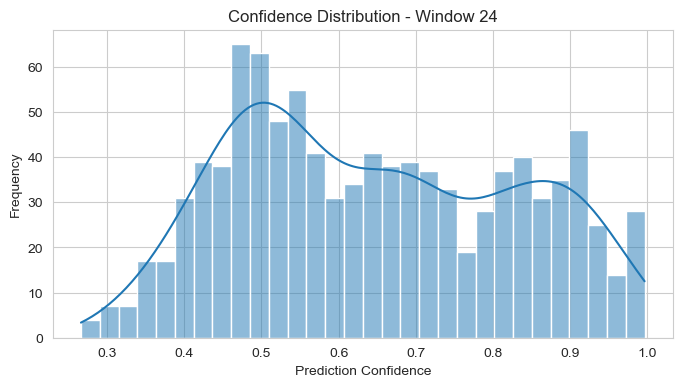

Window 24 - Confidence Mean: 0.6463453744647474, Median: 0.6294555068016052
Trades in window: 36


In [14]:
# Extract confidence values for the current validation window
conf_vals = X_full.loc[pred_indices, 'confidence'].dropna()

plt.figure(figsize=(8,4))
sns.histplot(conf_vals, bins=30, kde=True)
plt.title(f"Confidence Distribution - Window {w}")
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.show()

# Optionally, print confidence stats
print(f"Window {w} - Confidence Mean: {conf_vals.mean()}, Median: {conf_vals.median()}")
print(f"Trades in window: {trades}")

In [105]:
from collections import Counter

train_class_counts = Counter(train_y)
val_class_counts = Counter(val_y)

print(f"Train class distribution: {train_class_counts}")
print(f"Validation class distribution: {val_class_counts}")


Train class distribution: Counter({2: 3250, 3: 644, 1: 629, 4: 247, 0: 230})
Validation class distribution: Counter({2: 802, 1: 110, 3: 73, 4: 8, 0: 7})


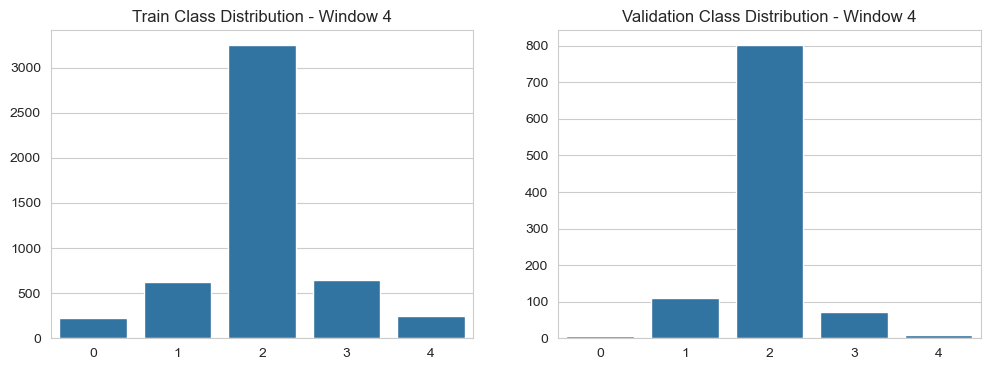

In [106]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

sns.barplot(x=list(train_class_counts.keys()), y=list(train_class_counts.values()), ax=ax[0])
ax[0].set_title(f"Train Class Distribution - Window {w}")

sns.barplot(x=list(val_class_counts.keys()), y=list(val_class_counts.values()), ax=ax[1])
ax[1].set_title(f"Validation Class Distribution - Window {w}")

plt.show()


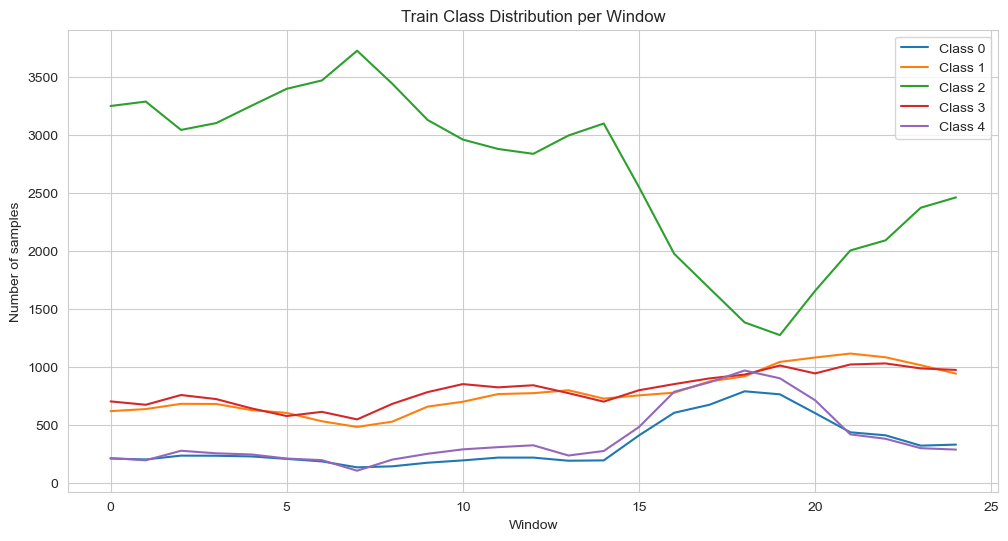

In [93]:
from collections import Counter
import matplotlib.pyplot as plt

train_class_distributions = []

for w, start in enumerate(range(0, len(X_full) - window_size - val_size - steps, step)):
    train_y = y[start : start + window_size]
    counts = Counter(train_y)
    train_class_distributions.append([counts.get(i, 0) for i in range(5)])

train_class_distributions = np.array(train_class_distributions)

plt.figure(figsize=(12,6))
for cls in range(5):
    plt.plot(train_class_distributions[:, cls], label=f'Class {cls}')
plt.title('Train Class Distribution per Window')
plt.xlabel('Window')
plt.ylabel('Number of samples')
plt.legend()
plt.show()


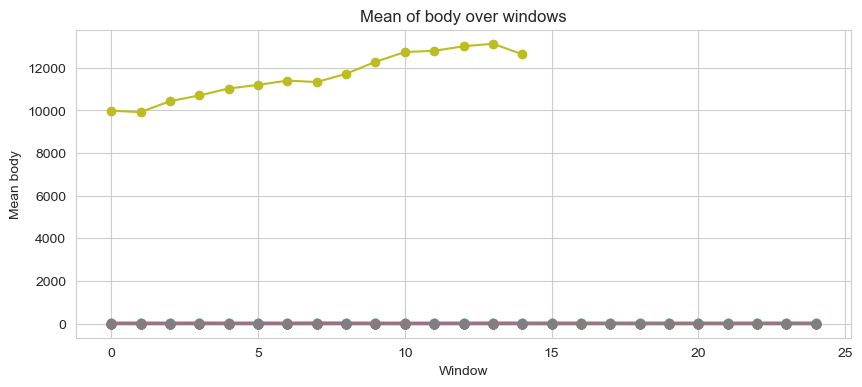

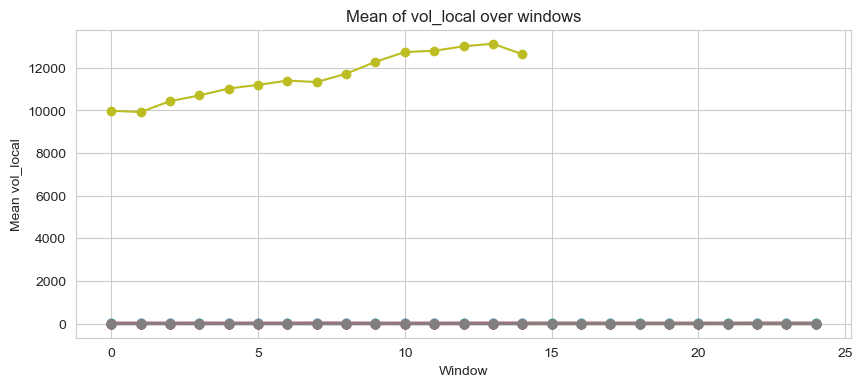

In [74]:
features_to_plot = X_full.columns[7:9]  # pick a few key features to avoid clutter

for feat in features_to_plot:
    plt.figure(figsize=(10,4))
    values = [X_full.iloc[start + window_size : start + window_size + val_size].mean() 
              for start in range(0, len(X_full) - window_size - val_size - steps, step)]
    plt.plot(values, marker='o')
    plt.title(f'Mean of {feat} over windows')
    plt.xlabel('Window')
    plt.ylabel(f'Mean {feat}')
    plt.show()


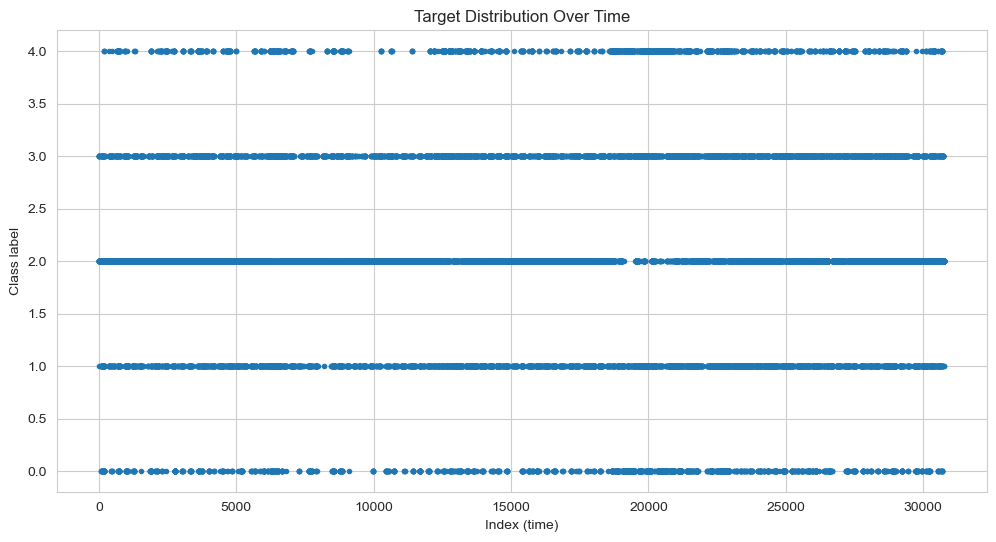

In [95]:
plt.figure(figsize=(12,6))
plt.plot(range(len(y)), y, marker='.', linestyle='none')
plt.title('Target Distribution Over Time')
plt.xlabel('Index (time)')
plt.ylabel('Class label')
plt.show()


<Axes: >

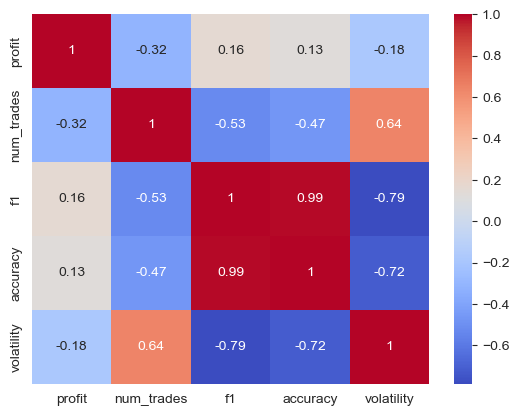

In [75]:
df_stats = pd.DataFrame({
    'profit': profit_per_window,
    'num_trades': trade_per_window,
    'f1': f1_per_window,
    'accuracy': acc_per_window,
    'volatility': vol_per_window
})

sns.heatmap(df_stats.corr(), annot=True, cmap='coolwarm')

In [76]:
generate_model_report_pdf(
    steps,
    extra_steps,
    window_indices,
    f1_per_window,
    acc_per_window,
    profit_per_window,
    trade_per_window,
    vol_per_window,
    initial_account_balance,
    window_size,
    val_size,
    step,
    cost_per_trade,
    pip_value_per_standard_lot,
    risk_per_trade_percentage,
    winning_trades,
    losing_trades,
    profit_per_class,
    trades_per_class,
    threshold,
    report_filename="model_no-1trades_new_vol_2025_eurusd.pdf"
)

C:\Users\marti\AppData\Local\Temp\ipykernel_16100\716935766.py:263: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", "B", 16)
C:\Users\marti\AppData\Local\Temp\ipykernel_16100\716935766.py:264: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, "Trading Model Performance Report", 0, 1, "C")
C:\Users\marti\AppData\Local\Temp\ipykernel_16100\716935766.py:265: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", "", 10)
C:\Users\marti\AppData\Local\Temp\ipykernel_16100\716935766.py:266: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}", 0, 1, "C")
C:\Users\


Report generated successfully: model_no-1trades_new_vol_2025_eurusd.pdf
